<a href="https://colab.research.google.com/github/NethsanduKumarasinghe/EN3160_Assignment_01/blob/main/EN3160_Assignment_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EN3160 Assignment 1
## Intensity Transformations and Neighborhood Filtering

**Name:** Kumarasinghe M. N.  
**Index:** 230355X

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving images.zip to images.zip


In [ ]:
import zipfile

with zipfile.ZipFile("images.zip", "r") as zip_ref:
    zip_ref.extractall("/content")

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

## Question 1

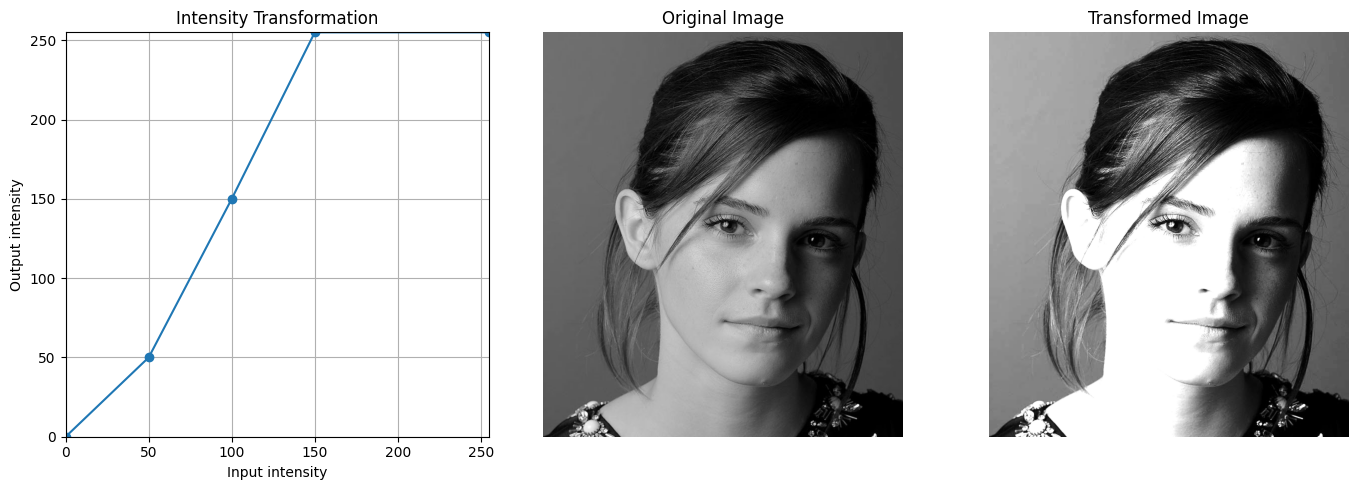

In [ ]:
# Load image
image_path = "/content/images/q1.jpeg"
im = cv.imread(image_path, cv.IMREAD_GRAYSCALE)

# Intensity transformation function
def intensity_transform(im, breakpoints):
    breakpoints = np.asarray(breakpoints, dtype=np.float32)

    x = breakpoints[:, 0]
    y = breakpoints[:, 1]

    if np.any(np.diff(x) <= 0):
        raise ValueError("Input breakpoints must be increasing")

    im_float = im.astype(np.float32)
    output = np.zeros_like(im_float)

    for i in range(len(x) - 1):
        x0, x1 = x[i], x[i + 1]
        y0, y1 = y[i], y[i + 1]

        mask = (im_float >= x0) & (im_float <= x1)

        output[mask] = y0 + (im_float[mask] - x0) * (y1 - y0) / (x1 - x0)

    return np.clip(output, 0, 255).astype(np.uint8)


# Given breakpoints
breakpoints = np.array([
    [0, 0],
    [50, 50],
    [100, 150],
    [150, 255],
    [255, 255]
])

# Apply transformation
transformed = intensity_transform(im, breakpoints)


# Display transformation and images
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.plot(breakpoints[:, 0], breakpoints[:, 1], 'o-')
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Intensity Transformation")
plt.grid()

plt.subplot(1, 3, 2)
plt.imshow(im, cmap="gray", vmin=0, vmax=255)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(transformed, cmap="gray", vmin=0, vmax=255)
plt.title("Transformed Image")
plt.axis("off")

plt.tight_layout()
plt.show()